In [1]:
!pip install osmnx folium matplotlib numpy --quiet

import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.0 MB/s eta 0:00:00


In [2]:
# Download Bengaluru drive network from OSM
G = ox.graph_from_place("Bengaluru, Karnataka, India", network_type="drive")

print(f"Nodes: {len(G.nodes)}")
print(f"Edges: {len(G.edges)}")

# Save for reuse
ox.save_graphml(G, filepath="bengaluru_roads.graphml")

Nodes: 155365
Edges: 393695


In [3]:
# Full computation is slow on 50K nodes
# Use k=500 approximation — standard for large graphs
centrality = nx.betweenness_centrality(
    G, 
    k=500,           # sample 500 pivot nodes for approximation
    weight='length', # weight by road length, not just hops
    normalized=True
)

print(f"Max centrality: {max(centrality.values()):.4f}")
print(f"Mean centrality: {np.mean(list(centrality.values())):.4f}")

# Assign centrality as node attribute
nx.set_node_attributes(G, centrality, 'betweenness')

Max centrality: 0.0780
Mean centrality: 0.0014


/tmp/ipykernel_58/4026868237.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlOrRd')  # yellow → orange → red


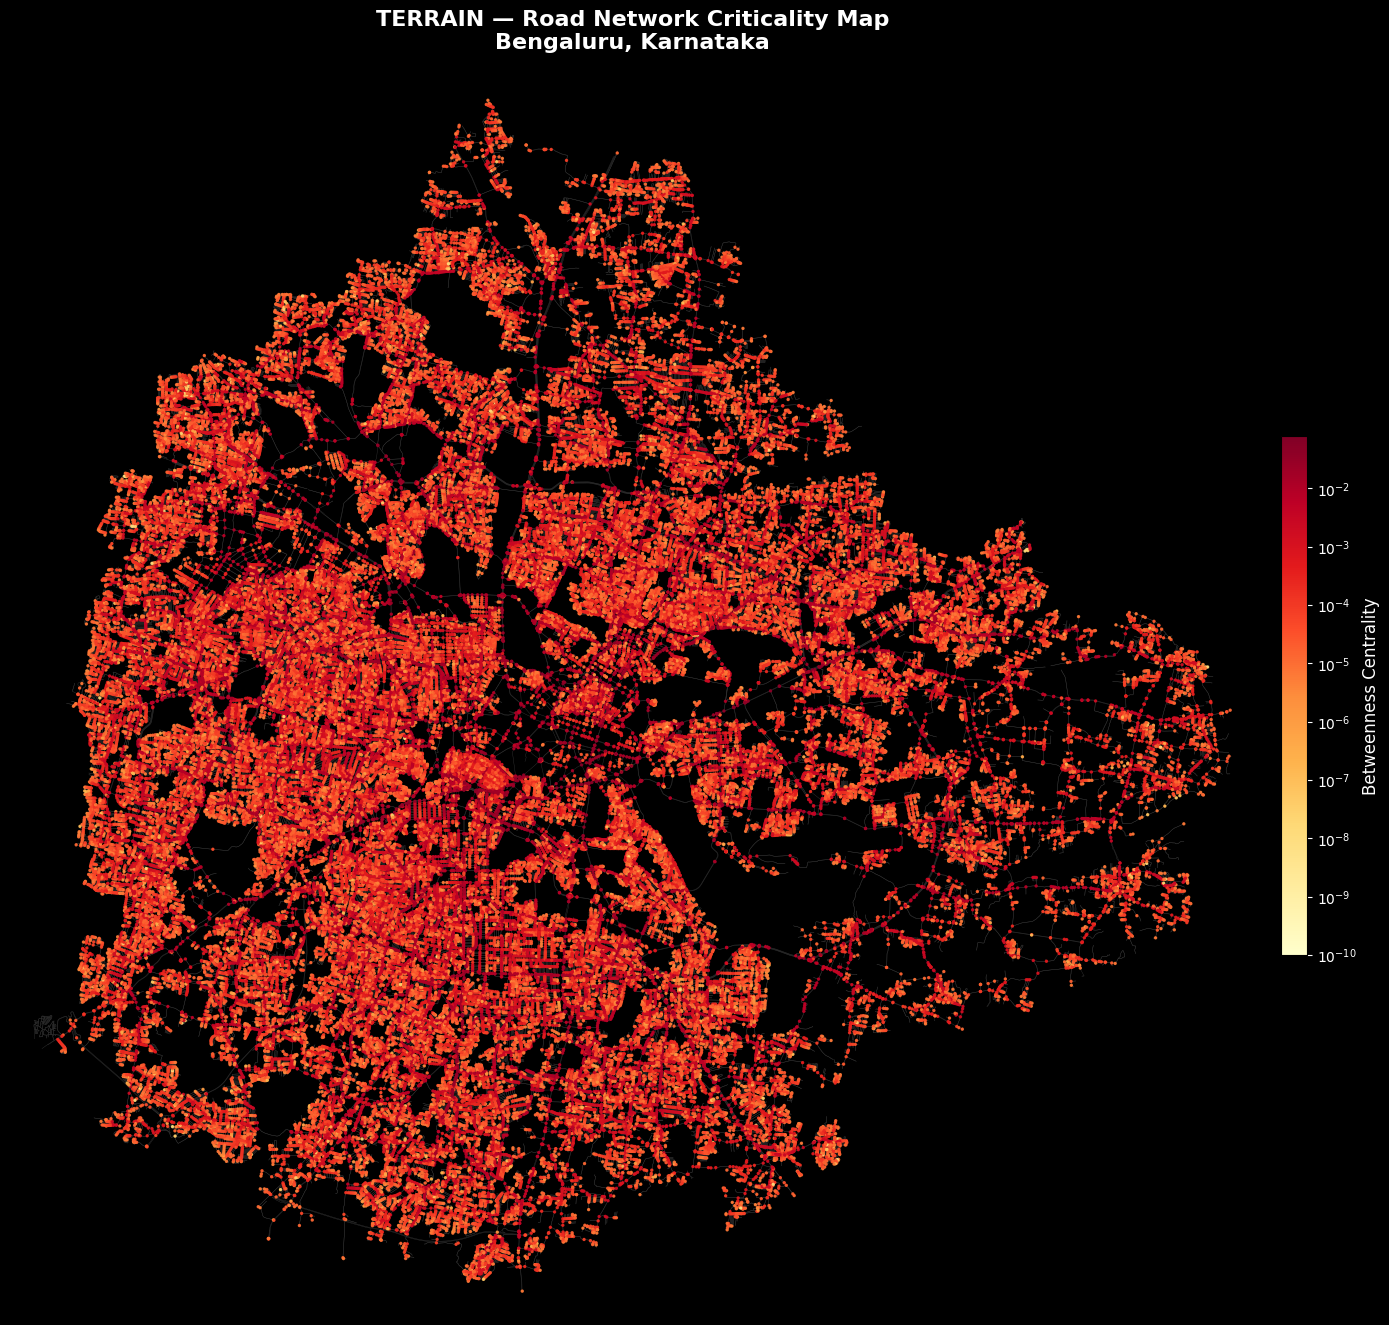

Saved.


In [4]:
# Extract node positions and centrality values
nodes, data = zip(*G.nodes(data=True))
xs = [d['x'] for d in data]
ys = [d['y'] for d in data]
centrality_values = [centrality.get(n, 0) for n in nodes]

# Normalize for color mapping
norm = mcolors.LogNorm(
    vmin=max(min(centrality_values), 1e-10),
    vmax=max(centrality_values)
)
cmap = cm.get_cmap('YlOrRd')  # yellow → orange → red
colors = [cmap(norm(v)) for v in centrality_values]

# Plot
fig, ax = plt.subplots(figsize=(14, 14), facecolor='black')
ax.set_facecolor('black')

# Draw edges first (light grey, thin)
ox.plot_graph(
    G, ax=ax,
    node_size=0,
    edge_color='#333333',
    edge_linewidth=0.3,
    show=False,
    close=False
)

# Draw nodes colored by centrality
ax.scatter(
    xs, ys,
    c=centrality_values,
    cmap='YlOrRd',
    norm=norm,
    s=2,
    zorder=5,
    alpha=0.9
)

# Colorbar
sm = cm.ScalarMappable(cmap='YlOrRd', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label('Betweenness Centrality', color='white', fontsize=12)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

ax.set_title(
    'TERRAIN — Road Network Criticality Map\nBengaluru, Karnataka',
    color='white', fontsize=16, fontweight='bold', pad=20
)
ax.axis('off')

plt.tight_layout()
plt.savefig('bengaluru_criticality_heatmap.png', dpi=300, bbox_inches='tight',
            facecolor='black')
plt.show()
print("Saved.")

In [5]:
# Top 10 most critical nodes
top_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 Gatekeeper Nodes:")
print("-" * 45)
for i, (node, score) in enumerate(top_nodes, 1):
    node_data = G.nodes[node]
    print(f"{i}. Node {node} | Score: {score:.4f} | "
          f"Lat: {node_data['y']:.4f}, Lon: {node_data['x']:.4f}")

Top 10 Gatekeeper Nodes:
---------------------------------------------
1. Node 10043357422 | Score: 0.0780 | Lat: 12.9662, Lon: 77.6067
2. Node 2473493601 | Score: 0.0681 | Lat: 12.9662, Lon: 77.6068
3. Node 249076473 | Score: 0.0675 | Lat: 12.9641, Lon: 77.5768
4. Node 263155937 | Score: 0.0582 | Lat: 12.9819, Lon: 77.5948
5. Node 60952254 | Score: 0.0582 | Lat: 12.9709, Lon: 77.6048
6. Node 12145487313 | Score: 0.0578 | Lat: 12.9921, Lon: 77.6042
7. Node 12153028221 | Score: 0.0576 | Lat: 12.9664, Lon: 77.5739
8. Node 248455485 | Score: 0.0559 | Lat: 12.9719, Lon: 77.6070
9. Node 320647365 | Score: 0.0555 | Lat: 12.9642, Lon: 77.5769
10. Node 1232686162 | Score: 0.0548 | Lat: 12.9767, Lon: 77.5992
